# NB4: Unified Predictive Models

**Narrative Framing**
* What question this notebook addresses: This notebook implements the specified sections to address the statistical analysis of the ground truth transition and performance impact.
* Which GT is being used as primary: Platinum GT
* Which KL1 strategy is active: Explicitly switchable (Default Strategy A - Exclusion)
* Central Narrative: Public medical imaging repository labels contain systematic, directionally biased noise that is invisible without platinum standard validation, and this noise quantifiably corrupts the performance metrics of annotation studies, AI benchmarks, and psychometric predictors derived from them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import pingouin as pg
import warnings
import helpers

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Load Data
KL1_STRATEGY = 'exclude' 
df = helpers.load_data(KL1_STRATEGY)
df_part = helpers.participant_summary(df)

df['human_correct_plat_int'] = df['human_correct_plat'].astype(int)

print("Setup Complete: Data loaded using 'exclude' strategy.")

Setup Complete: Data loaded using 'exclude' strategy.


## Section 1 — Model building

In [2]:
print("--- GEE Model Comparisons ---")

# M1: Condition Only
m1 = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai'))", 
             groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

# M2: Condition + Key Traits
m2 = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) + big5_conscientiousness + iq_score + big5_neuroticism", 
             groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

# M3: Full model (With Interaction)
m3 = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) * iq_score + big5_conscientiousness", 
             groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

print("M1 QIC (lower is better):", m1.qic())
print("M2 QIC:", m2.qic())
print("M3 QIC:", m3.qic())

print("\n--- Best Performing Model (M2 or M3) Summary ---")
print(m2.summary())

--- GEE Model Comparisons ---
M1 QIC (lower is better): (3242.1185683763024, 3245.2083712442336)
M2 QIC: (2971.672054133601, 2979.42146886926)
M3 QIC: (2977.597205190699, 2985.572861974111)

--- Best Performing Model (M2 or M3) Summary ---
                                GEE Regression Results                               
Dep. Variable:        human_correct_plat_int   No. Observations:                 2943
Model:                                   GEE   No. clusters:                       58
Method:                          Generalized   Min. cluster size:                  27
                        Estimating Equations   Max. cluster size:                  54
Family:                             Binomial   Mean cluster size:                50.7
Dependence structure:           Independence   Num. iterations:                     2
Date:                       Mon, 20 Apr 2026   Scale:                           1.000
Covariance type:                      robust   Time:                    

/Users/baltaymarci/Documents/Feel Good AI/PerCoTate/.venv/lib/python3.9/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


## Section 2 — Mediation analysis

In [3]:
print("--- Mediation: AI Feedback -> Confidence -> Accuracy ---")
df_med = df.dropna(subset=['final_confidence', 'human_correct_plat_int', 'condition']).copy()
df_med['condition_num'] = (df_med['condition'] == 'ai').astype(int)

med = pg.mediation_analysis(data=df_med, x='condition_num', m='final_confidence', y='human_correct_plat_int', seed=42)
print("Mediation Summary:")
print(med)


--- Mediation: AI Feedback -> Confidence -> Accuracy ---
Mediation Summary:
                   path      coef        se          pval  CI[2.5%]  \
0  final_confidence ~ X  0.033216  0.049521  5.024316e-01 -0.063880   
1  Y ~ final_confidence  0.076134  0.004881  6.288305e-53  0.066563   
2                 Total  0.024580  0.014201  8.357044e-02 -0.003264   
3                Direct  0.022054  0.013695  1.074291e-01 -0.004799   
4              Indirect  0.002526  0.003632  5.040000e-01 -0.004602   

   CI[97.5%]  sig  
0   0.130313   No  
1   0.085704  Yes  
2   0.052423   No  
3   0.048907   No  
4   0.009935   No  


## Section 3 — Image difficulty as moderator

--- GEE: Accuracy ~ AI Feedback * Difficulty (GT KL) ---
                                GEE Regression Results                               
Dep. Variable:        human_correct_plat_int   No. Observations:                 3213
Model:                                   GEE   No. clusters:                       68
Method:                          Generalized   Min. cluster size:                  27
                        Estimating Equations   Max. cluster size:                  54
Family:                             Binomial   Mean cluster size:                47.2
Dependence structure:           Independence   Num. iterations:                     2
Date:                       Mon, 20 Apr 2026   Scale:                           1.000
Covariance type:                      robust   Time:                         11:40:56
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

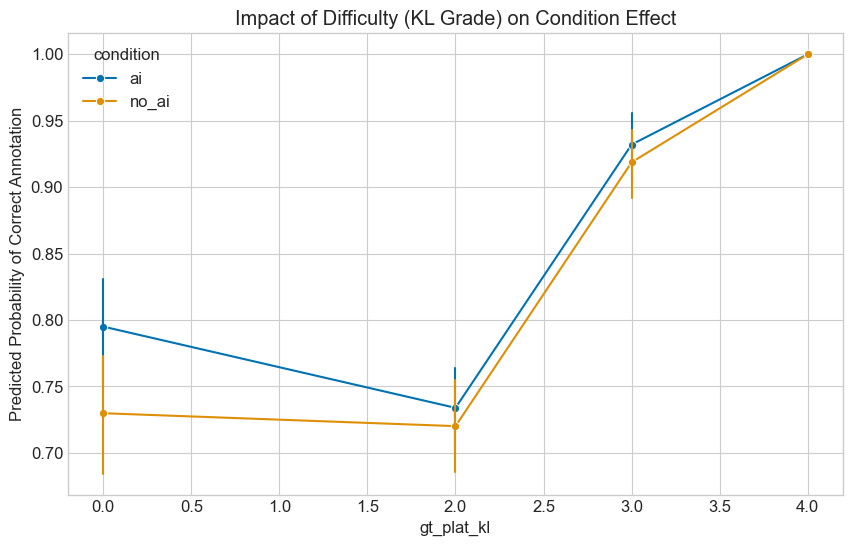

In [4]:
print("--- GEE: Accuracy ~ AI Feedback * Difficulty (GT KL) ---")
m_diff = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) * gt_plat_kl", 
                 groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()
print(m_diff.summary())

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='gt_plat_kl', y='human_correct_plat_int', hue='condition', marker='o', err_style='bars')
plt.title("Impact of Difficulty (KL Grade) on Condition Effect")
plt.ylabel("Predicted Probability of Correct Annotation")
plt.show()

## Section 4 — Summary results table

In [5]:
res_table = pd.DataFrame({
    'M1_Coef': m1.params, 'M1_P': m1.pvalues,
    'M2_Coef': m2.params, 'M2_P': m2.pvalues,
    'M3_Coef': m3.params, 'M3_P': m3.pvalues
})
print("Final Publication Model Summary (Standardized Coefficients):")
print(res_table.round(3))

Final Publication Model Summary (Standardized Coefficients):
                                                 M1_Coef   M1_P  M2_Coef  \
C(condition, Treatment('no_ai'))[T.ai]             0.152  0.125    0.143   
C(condition, Treatment('no_ai'))[T.ai]:iq_score      NaN    NaN      NaN   
Intercept                                          1.290  0.000    0.970   
big5_conscientiousness                               NaN    NaN   -0.028   
big5_neuroticism                                     NaN    NaN    0.159   
iq_score                                             NaN    NaN   -0.040   

                                                  M2_P  M3_Coef   M3_P  
C(condition, Treatment('no_ai'))[T.ai]           0.184    0.081  0.547  
C(condition, Treatment('no_ai'))[T.ai]:iq_score    NaN    0.053  0.263  
Intercept                                        0.022    1.574  0.000  
big5_conscientiousness                           0.734   -0.061  0.440  
big5_neuroticism                         